#### DBSCAN(Density-Based Spatial Clustering of Applications with Noise) Implementation

DBSCAN two useful abilities:

- Find clusters based on density
- Identify noise/outliers

DBSCAN has two important parameters:
- eps
- min_samples

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN

# 1. Create dataset
df = pd.DataFrame({
    "X": [10, 2, 5, 8, 4, 3, 1, 7],
    "Y": [2, 3, 6, 7, 6, 8, 2, 9]
})

print(df)

    X  Y
0  10  2
1   2  3
2   5  6
3   8  7
4   4  6
5   3  8
6   1  2
7   7  9


In [13]:
# 2. Select features
X = df[["X", "Y"]]

In [14]:
# 3. Create DBSCAN model
""" 
eps - The maximum distance we consider to be a point's neighborhood.
min_samples- The minimum number of points required in that neighborhood for a point to be considered a core point."""

dbscan=DBSCAN(eps=3,min_samples=3)

# 4. Train the model
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",3
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[int64](3, 2)","[[5,6], [4,6], [3,8]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](3,)","[2,4,5]"


In [15]:
# 5. Add cluster labels
df["Clusters"]=dbscan.labels_

# 6. Display results
df

#Cluster = -1 =Noise/Outliers

,X,Y,Clusters
0,10,2,-1
1,2,3,-1
2,5,6,0
3,8,7,-1
4,4,6,0
5,3,8,0
6,1,2,-1
7,7,9,-1


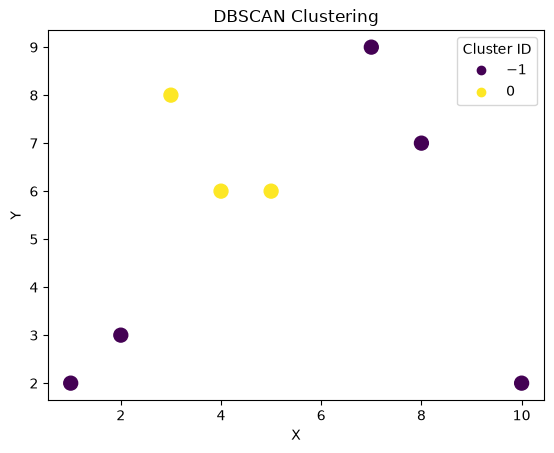

In [20]:
# 7. Plot clusters
scatter_plot=plt.scatter(
    df["X"],
    df["Y"],
    c=df["Clusters"],
    cmap="viridis", 
    s=100
)

plt.legend(*scatter_plot.legend_elements(), title="Cluster ID", loc="upper right")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("DBSCAN Clustering")

plt.show()

In [22]:

import numpy as np
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 1. Create dataset
data=np.array([[1,2],[2,1],[3,3],[4,2],[5,5],[6,7],[9,9],[21,21]])

# 2. Fit the model and extract labels
clustering = DBSCAN(eps=3, min_samples=2).fit(data)
labels = clustering.labels_
print("Cluster Labels:", labels)

# 3. Slice the NumPy array to separate X and Y
# data[:, 0] means "get all rows, but only the 0th index (first column)"
x_coords = data[:, 0] 
y_coords = data[:, 1]

Cluster Labels: [ 0  0  0  0  0  0 -1 -1]


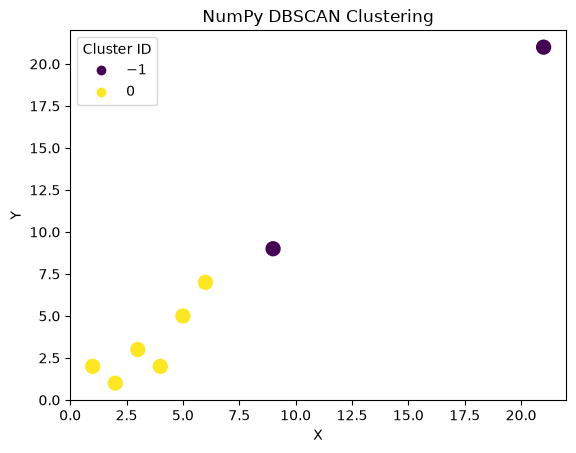

In [23]:
# 4. Plot as a scatter, assigning the labels to 'c' (color)
scatter = plt.scatter(x_coords, y_coords, c=labels, cmap="viridis", s=100)

# 5. Extract the auto-generated colors to build the legend
plt.legend(*scatter.legend_elements(), title="Cluster ID", loc="upper left")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("NumPy DBSCAN Clustering")
plt.show()